# Task 1: Clickbait Spoiler Type Classification — EDA

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [3]:
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

train = load_jsonl('train.jsonl')
val   = load_jsonl('val.jsonl')
test  = load_jsonl('test.jsonl')

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')

Train: 3200 | Val: 400 | Test: 400


In [4]:
def to_df(records, has_labels=True):
    rows = []
    for r in records:
        row = {
            'postText': r['postText'][0] if r['postText'] else '',
            'targetTitle': r.get('targetTitle', ''),
            'targetDescription': r.get('targetDescription', ''),
            'targetKeywords': r.get('targetKeywords', ''),
            'n_paragraphs': len(r.get('targetParagraphs', [])),
            'paragraphs_text': ' '.join(r.get('targetParagraphs', [])),
            'platform': r.get('postPlatform', ''),
        }
        if has_labels:
            row['label'] = r['tags'][0]
            row['spoiler'] = r['spoiler'][0] if r.get('spoiler') else ''
            row['n_spoilers'] = len(r.get('spoiler', []))
        rows.append(row)
    return pd.DataFrame(rows)

train_df = to_df(train)
val_df   = to_df(val)
test_df  = to_df(test, has_labels=False)

train_df.head(3)

,postText,targetTitle,targetDescription,targetKeywords,n_paragraphs,paragraphs_text,platform,label,spoiler,n_spoilers
0,"Wes Welker Wanted Dinner With Tom Brady, But P...","Wes Welker Wanted Dinner With Tom Brady, But P...",It'll be just like old times this weekend for ...,"new england patriots, ricky doyle, top stories,",7,It’ll be just like old times this weekend for ...,reddit,passage,how about that morning we go throw?,1
1,NASA sets date for full recovery of ozone hole,Hole In Ozone Layer Expected To Make Full Reco...,2070 is shaping up to be a great year for Moth...,"ozone layer,ozone hole determined by weather,M...",10,2070 is shaping up to be a great year for Moth...,Twitter,phrase,2070,1
2,This is what makes employees happy -- and it's...,Intellectual Stimulation Trumps Money For Empl...,By: Chad Brooks \r\nPublished: 09/18/2013 06:4...,"employee happiness money,employee happiness in...",10,"Despite common belief, money isn't the key to ...",Twitter,phrase,intellectual stimulation,1


## 2. Label Distribution

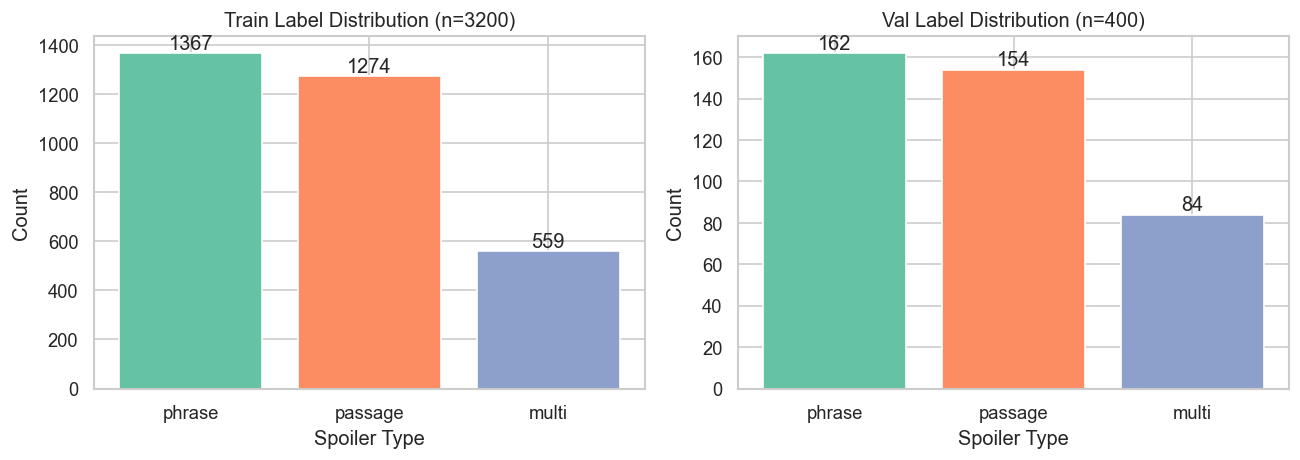

Train label %:
label
phrase     42.7
passage    39.8
multi      17.5
Name: count, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (df, split) in zip(axes, [(train_df, 'Train'), (val_df, 'Val')]):
    counts = df['label'].value_counts()
    bars = ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', 3))
    ax.bar_label(bars, fmt='%d')
    ax.set_title(f'{split} Label Distribution (n={len(df)})')
    ax.set_xlabel('Spoiler Type')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Train label %:')
print((train_df['label'].value_counts() / len(train_df) * 100).round(1))

## 3. Text Length Analysis

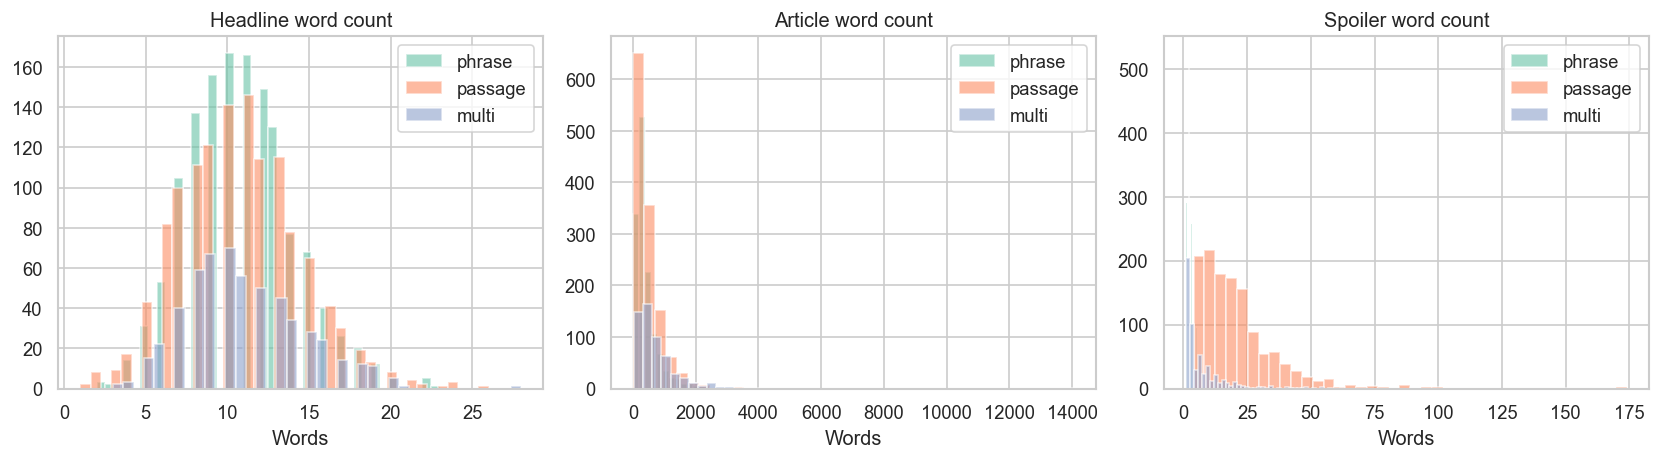

In [6]:
train_df['postText_len']    = train_df['postText'].str.split().str.len()
train_df['paragraph_words'] = train_df['paragraphs_text'].str.split().str.len()
train_df['spoiler_len']     = train_df['spoiler'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
    ['postText_len', 'paragraph_words', 'spoiler_len'],
    ['Headline word count', 'Article word count', 'Spoiler word count']):
    for label in ['phrase', 'passage', 'multi']:
        subset = train_df[train_df['label'] == label][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, label=label)
    ax.set_title(title)
    ax.set_xlabel('Words')
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
train_df.groupby('label')[['postText_len', 'paragraph_words', 'spoiler_len', 'n_paragraphs']].median().round(1)

,postText_len,paragraph_words,spoiler_len,n_paragraphs
label,,,,
multi,11.0,531.0,4.0,16.0
passage,11.0,353.5,17.0,10.0
phrase,11.0,308.0,2.0,9.0


## 4. Spoiler Position Analysis

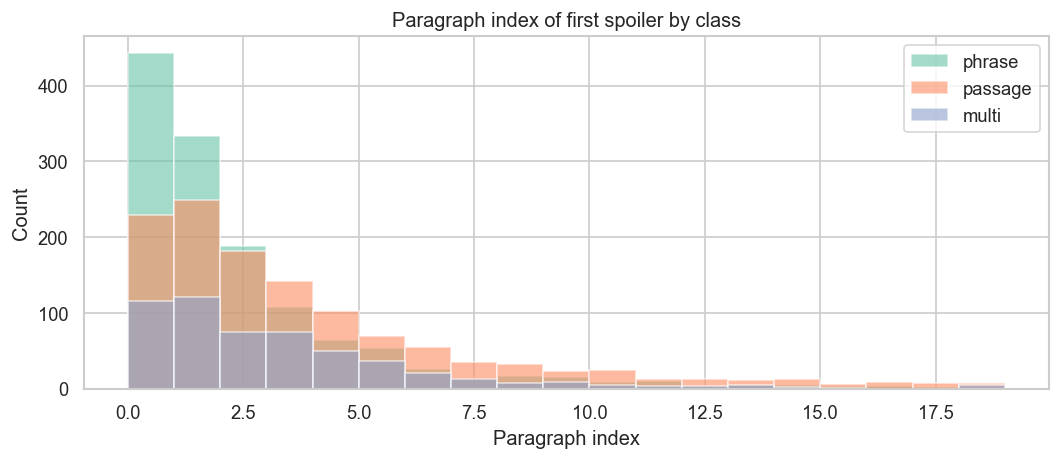

In [8]:
# Which paragraph does the spoiler typically appear in?
para_indices = []
for r in train:
    label = r['tags'][0]
    positions = r.get('spoilerPositions', [])
    if positions:
        first_para = positions[0][0][0]  # paragraph index of first spoiler start
        para_indices.append({'label': label, 'para_idx': first_para})

pos_df = pd.DataFrame(para_indices)

fig, ax = plt.subplots(figsize=(9, 4))
for label in ['phrase', 'passage', 'multi']:
    subset = pos_df[pos_df['label'] == label]['para_idx']
    ax.hist(subset, bins=range(0, 20), alpha=0.6, label=label)
ax.set_title('Paragraph index of first spoiler by class')
ax.set_xlabel('Paragraph index')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Number of Spoilers per Sample (multi vs others)

In [9]:
n_spoilers = []
for r in train:
    n_spoilers.append({'label': r['tags'][0], 'n_spoilers': len(r.get('spoiler', []))})

ns_df = pd.DataFrame(n_spoilers)
print(ns_df.groupby('label')['n_spoilers'].value_counts().unstack(fill_value=0))

n_spoilers    1    2   3   4    5   6   8   10
label                                         
multi         20  209  50  22  249   7   1   1
passage     1274    0   0   0    0   0   0   0
phrase      1367    0   0   0    0   0   0   0


## 6. Headline Keyword Patterns

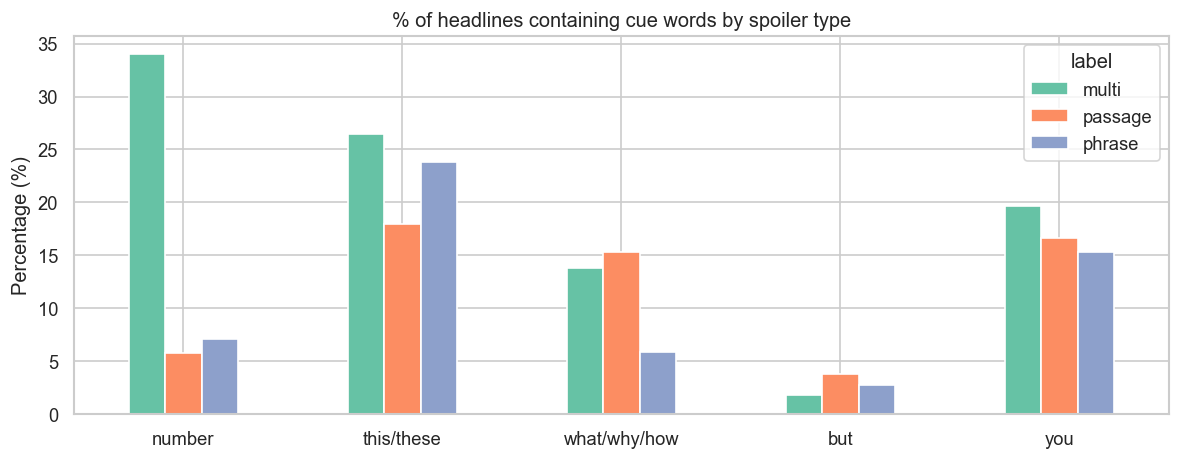

,number,this/these,what/why/how,but,you
label,,,,,
multi,34.0,26.5,13.8,1.8,19.7
passage,5.8,18.0,15.3,3.8,16.6
phrase,7.1,23.8,5.9,2.8,15.3


In [10]:
# Classic clickbait cue words — do they correlate with spoiler type?
cue_words = {
    'number':    lambda t: any(w.isdigit() for w in t.split()),
    'this/these': lambda t: any(w.lower() in ('this', 'these') for w in t.split()),
    'what/why/how': lambda t: t.split()[0].lower() in ('what', 'why', 'how', 'who', 'when', 'where'),
    'but':       lambda t: 'but' in t.lower(),
    'you':       lambda t: 'you' in t.lower().split(),
}

for cue, fn in cue_words.items():
    train_df[f'cue_{cue}'] = train_df['postText'].apply(fn)

cue_cols = [c for c in train_df.columns if c.startswith('cue_')]
cue_by_label = train_df.groupby('label')[cue_cols].mean().round(3) * 100
cue_by_label.columns = [c.replace('cue_', '') for c in cue_by_label.columns]

cue_by_label.T.plot(kind='bar', figsize=(10, 4), rot=0)
plt.title('% of headlines containing cue words by spoiler type')
plt.ylabel('Percentage (%)')
plt.legend(title='label')
plt.tight_layout()
plt.show()

cue_by_label

## 7. Platform Distribution

In [11]:
print('Platform distribution in train:')
print(train_df['platform'].value_counts())

Platform distribution in train:
platform
Twitter     1530
reddit      1150
Facebook     520
Name: count, dtype: int64


## 8. Sample Examples per Class

In [12]:
for label in ['phrase', 'passage', 'multi']:
    print(f'\n=== {label.upper()} ===')
    for _, row in train_df[train_df['label'] == label].head(3).iterrows():
        print(f'  Headline : {row["postText"]}')
        print(f'  Spoiler  : {row["spoiler"]}')
        print()


=== PHRASE ===
  Headline : NASA sets date for full recovery of ozone hole
  Spoiler  : 2070

  Headline : This is what makes employees happy -- and it's not their paycheck
  Spoiler  : intellectual stimulation

  Headline : The perfect way to cook rice so that it's perfectly fluffy and NEVER sticks to the pan
  Spoiler  : in a rice cooker


=== PASSAGE ===
  Headline : Wes Welker Wanted Dinner With Tom Brady, But Patriots QB Had Better Idea
  Spoiler  : how about that morning we go throw?

  Headline : What happens if your new AirPods get lost or stolen, will Apple do anything?
  Spoiler  : Apple says that if AirPods are lost or stolen, you'll have to buy new ones, just like any other Apple product.

  Headline : The Reason Why Gabor Kiraly Wears THOSE Trackie Bottoms
  Spoiler  : "The more good games I had in them, the more I got used to them.


=== MULTI ===
  Headline : Passion is overrated — 7 work habits you need instead
  Spoiler  : Purpose connects us to something bigger and i

## 9. Key Takeaways

- **Class imbalance**: phrase (42.7%), passage (39.8%), multi (17.5%) — use `class_weight='balanced'`
- **`multi` samples have multiple spoilers** (>1 `spoiler` entries) — the number of spoilers is a strong signal
- **Spoiler position**: `phrase` spoilers tend to appear at character-level spans, while `passage` covers full paragraph spans
- **Headline cue words**: numbers in headlines are more associated with `phrase`; "this/these" with `passage`
- **Article length**: `passage` samples tend to have more paragraphs than `phrase`
- **Feature strategy**: headline + title + description + first 3 paragraphs is a reasonable TF-IDF input